In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Read data
train_df = pd.read_csv('../titanic/train.csv')
test_df = pd.read_csv('../titanic/test.csv')

# Remove columns that are not needed for clustering
train_data = train_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked', 'Survived'])
test_data = test_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'])

# Handle missing data
train_data.fillna(train_data.median(numeric_only=True), inplace=True)
test_data.fillna(test_data.median(numeric_only=True), inplace=True)

# Convert categorical data
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1})
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1})

# Normalize data
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled = scaler.transform(test_data)

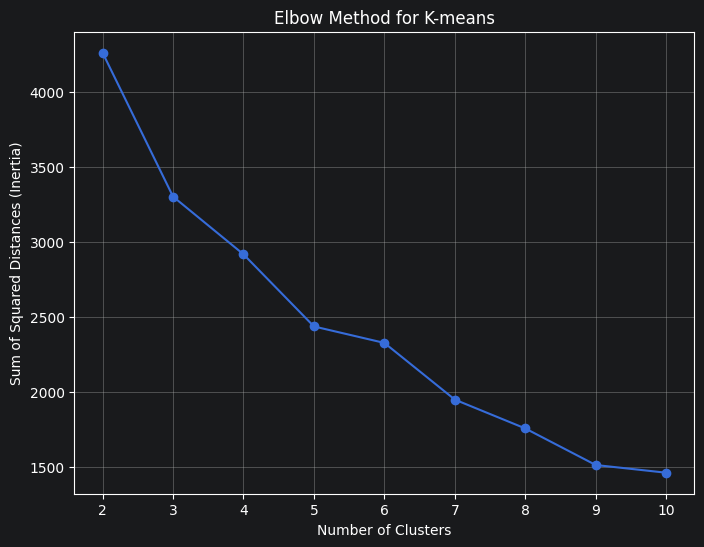

In [11]:
# Apply KMeans
kmeans_inertia = []
silhouette_scores = []
davies_bouldin_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(train_scaled)
    kmeans_inertia.append(kmeans.inertia_)

    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(train_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(train_scaled, labels))

# Elbow method plot for K-means
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), kmeans_inertia, marker='o', label='Inertia')
plt.title('Elbow Method for K-means')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Distances (Inertia)')
plt.grid(True)
plt.show()

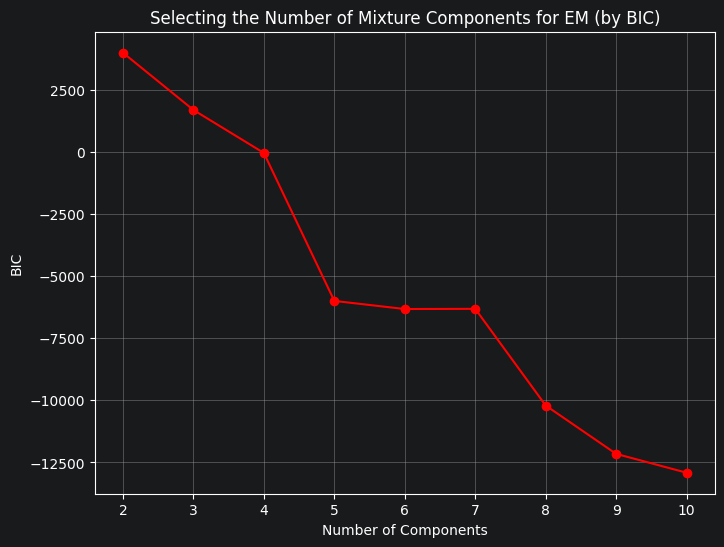

In [12]:
# Apply EM (Gaussian Mixture)
gm_bic = []
silhouette_gm = []
davies_bouldin_gm = []

for k in range(2, 11):
    gm = GaussianMixture(n_components=k, random_state=42)
    gm.fit(train_scaled)
    gm_bic.append(gm.bic(train_scaled))

    labels = gm.predict(train_scaled)
    silhouette_gm.append(silhouette_score(train_scaled, labels))
    davies_bouldin_gm.append(davies_bouldin_score(train_scaled, labels))

# BIC plot for Gaussian Mixture
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), gm_bic, marker='o', color='r')
plt.title('Selecting the Number of Mixture Components for EM (by BIC)')
plt.xlabel('Number of Components')
plt.ylabel('BIC')
plt.grid(True)
plt.show()

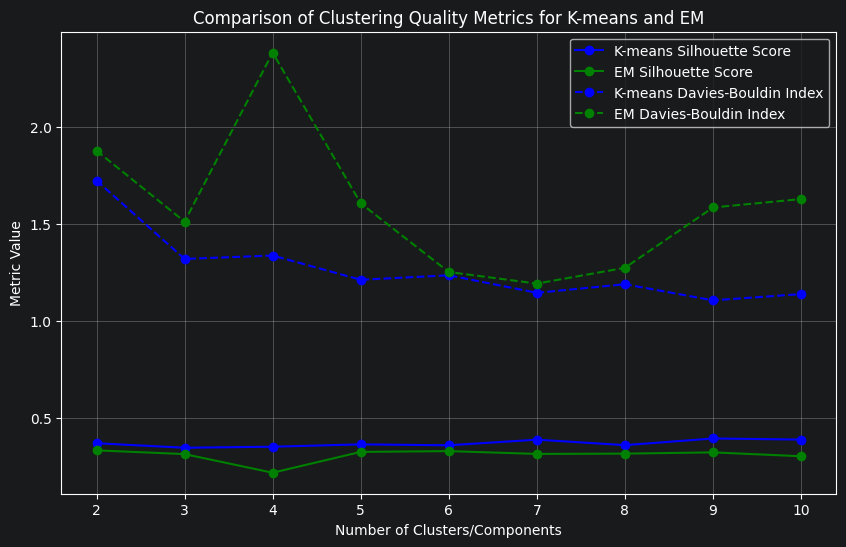

In [13]:
# Plot to compare K-means and EM by clustering quality metrics
plt.figure(figsize=(10, 6))

# Silhouette score
plt.plot(range(2, 11), silhouette_scores, marker='o', label='K-means Silhouette Score', color='blue')
plt.plot(range(2, 11), silhouette_gm, marker='o', label='EM Silhouette Score', color='green')

# Davies-Bouldin index
plt.plot(range(2, 11), davies_bouldin_scores, marker='o', linestyle='--', label='K-means Davies-Bouldin Index',
         color='blue')
plt.plot(range(2, 11), davies_bouldin_gm, marker='o', linestyle='--', label='EM Davies-Bouldin Index', color='green')

plt.title('Comparison of Clustering Quality Metrics for K-means and EM')
plt.xlabel('Number of Clusters/Components')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Determine the optimal number of clusters
optimal_k = 3  # Example value; choose the optimal K from the plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(train_scaled)

KMeans(n_clusters=3, random_state=42)

/var/folders/2g/hq1r334n4zj7rl5jy55bb59w0000gn/T/ipykernel_93550/4094157974.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.scatter(train_pca[:, 0], train_pca[:, 1], c=kmeans.labels_, cmap=plt.cm.get_cmap('Set1', optimal_k))


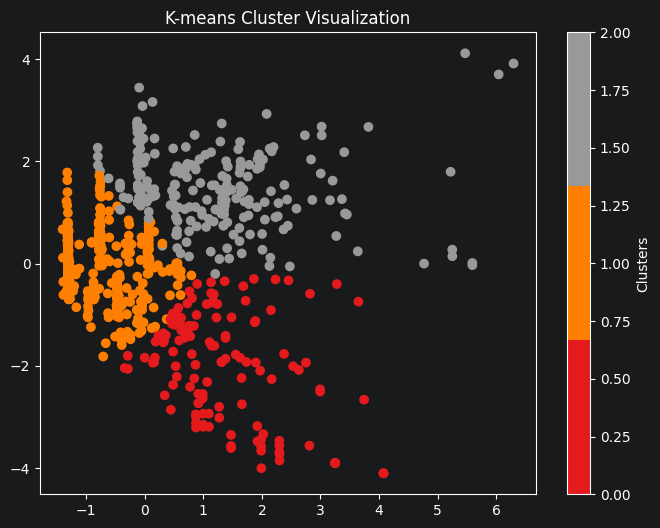

In [15]:
# Apply PCA to visualize K-means clusters
pca = PCA(n_components=2)
train_pca = pca.fit_transform(train_scaled)

# Use colors for clusters. If some variables are used in other plots, reuse the same colors
colors = ['blue', 'green', 'red']  # Example: blue and green are already used in the plots above, red is for the remaining clusters

plt.figure(figsize=(8, 6))
plt.scatter(train_pca[:, 0], train_pca[:, 1], c=kmeans.labels_, cmap=plt.cm.get_cmap('Set1', optimal_k))
plt.title('K-means Cluster Visualization')
plt.colorbar(label='Clusters')
plt.show()

In [16]:
# Print K-means cluster centers
print("K-means cluster centers:")
print(kmeans.cluster_centers_)

K-means cluster centers:
[[ 3.95470326e-01  5.84369291e-01 -9.67464683e-01  1.31966564e+00
   1.72894010e+00  6.26149438e-04]
 [ 5.45925472e-01 -2.45396764e-01 -7.92284625e-02 -2.92383535e-01
  -4.04844162e-01 -4.07364301e-01]
 [-1.43879394e+00  2.15410178e-01  7.23869314e-01 -9.61657108e-02
  -7.75129217e-02  9.06247878e-01]]


In [17]:
# Apply EM with the optimal number of components
gm = GaussianMixture(n_components=optimal_k, random_state=42)
gm.fit(train_scaled)

GaussianMixture(n_components=3, random_state=42)

In [18]:
# Print EM component centers
print("EM component centers:")
print(gm.means_)

EM component centers:
[[ 0.45215532  0.33882742 -0.64554635  1.00984326  1.3212386  -0.06285403]
 [ 0.51842851 -0.20091071 -0.01233428 -0.33026561 -0.47367361 -0.43487573]
 [-1.56610693  0.17368589  0.57225362 -0.09615693 -0.03079252  1.04702114]]
